# 10. Variational Mode Decomposition (VMD)
**Objective:** Transform raw sEMG temporal windows into Intrinsic Mode Functions (IMFs) to feed time-frequency structural data into advanced neural networks.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from src.config import PREPROCESSED_DIR
from src.vmd_extraction import extract_vmd_features

plt.style.use('seaborn-v0_8-whitegrid')

### 1. Load Preprocessed Time-Domain Windows (Subject 1)

In [2]:
file_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1.h5")
with h5py.File(file_path, 'r') as f:
    X_bal = np.array(f['X'])
    y_bal = np.array(f['y']).astype(np.int64)
    reps_bal = np.array(f['reps'])

print(f"Original Time-Domain Shape: {X_bal.shape}")

Original Time-Domain Shape: (18630, 20, 10)


### 2. Apply VMD to Training Data
For this visualization, we will process a small subset (the first 500 windows) to quickly inspect the transformation physics before running it on the massive 18,000-window dataset.

In [3]:
# Extract exactly 3 IMFs (Low, Mid, High Frequency bands)
K_modes = 3

# Subset for rapid testing
X_subset = X_bal[:500] 
y_subset = y_bal[:500]

X_vmd_subset = extract_vmd_features(X_subset, K=K_modes, n_jobs=-1)

Starting parallel VMD extraction on 500 windows...
Extracting K=3 modes per channel. This may take a few minutes...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18765519866130134s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19050049781799316s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  76 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 106 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 220 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 288 tasks      | elap

VMD extraction complete. Output tensor shape: (500, 3, 20, 10)


[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 473 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    3.4s finished


### 3. Visualizing Intrinsic Mode Functions (IMFs)
Let's observe how VMD separated a complex raw muscle signal into fundamental frequency bands while preserving time.

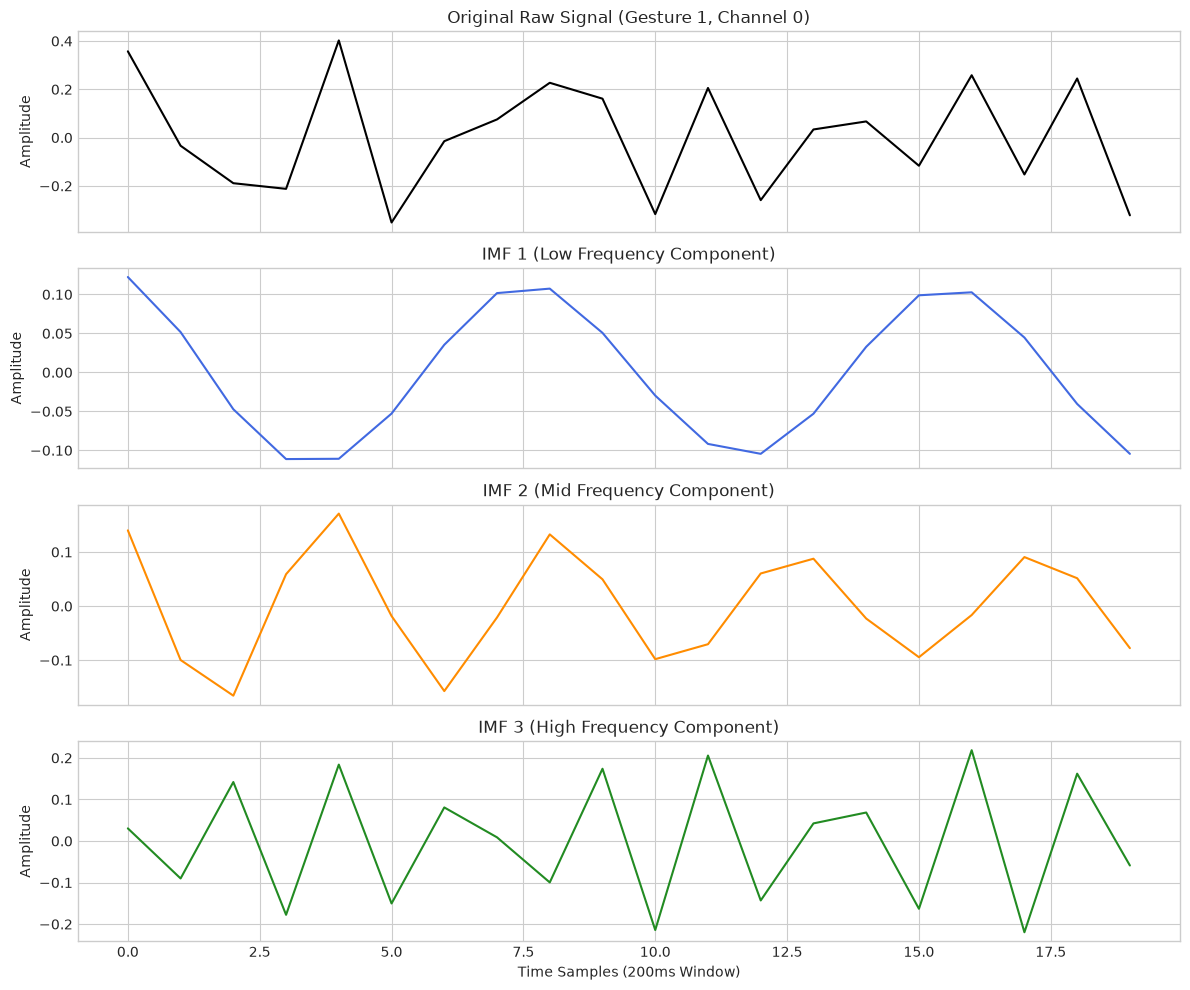

In [4]:
# Find an active gesture in our subset
active_idx = np.where(y_subset > 0)[0][10]
channel_idx = 0

raw_signal = X_subset[active_idx, :, channel_idx]
imf_1 = X_vmd_subset[active_idx, 0, :, channel_idx] # IMF1: Low Frequency
imf_2 = X_vmd_subset[active_idx, 1, :, channel_idx] # IMF2: Mid Frequency
imf_3 = X_vmd_subset[active_idx, 2, :, channel_idx] # IMF3: High Frequency

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(raw_signal, color='black', linewidth=1.5)
axes[0].set_title(f"Original Raw Signal (Gesture {y_subset[active_idx]}, Channel {channel_idx})")
axes[0].set_ylabel("Amplitude")

axes[1].plot(imf_1, color='royalblue')
axes[1].set_title("IMF 1 (Low Frequency Component)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(imf_2, color='darkorange')
axes[2].set_title("IMF 2 (Mid Frequency Component)")
axes[2].set_ylabel("Amplitude")

axes[3].plot(imf_3, color='forestgreen')
axes[3].set_title("IMF 3 (High Frequency Component)")
axes[3].set_xlabel("Time Samples (200ms Window)")
axes[3].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

### 4. Full Dataset VMD Extraction & Serialization
Processing all windows for Subject 1 and saving to HDF5 to accelerate downstream deep learning.

In [5]:
import time

print("Starting VMD extraction on the full dataset...")
start_time = time.time()

# Extract 3 IMFs for all 18,630 windows
X_vmd_full = extract_vmd_features(X_bal, K=3, n_jobs=-1)

elapsed = time.time() - start_time
print(f"Full extraction completed in {elapsed / 60:.2f} minutes.")

# Serialize the VMD tensor
vmd_h5_path = os.path.join(PREPROCESSED_DIR, "DB1_subject_1_VMD.h5")
with h5py.File(vmd_h5_path, 'w') as f:
    f.create_dataset('X_vmd', data=X_vmd_full, compression='gzip')
    f.create_dataset('y', data=y_bal)
    f.create_dataset('reps', data=reps_bal)

print(f"VMD Data serialized to {vmd_h5_path}")

Starting VMD extraction on the full dataset...
Starting parallel VMD extraction on 18630 windows...
Extracting K=3 modes per channel. This may take a few minutes...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04364824295043945s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1243898868560791s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 236 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 296 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 364 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 432 tasks      | elaps

VMD extraction complete. Output tensor shape: (18630, 3, 20, 10)
Full extraction completed in 1.30 minutes.
VMD Data serialized to /workspaces/TCC/data/preprocessed/DB1_subject_1_VMD.h5
